In [7]:
#Libraries
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

In [8]:
# Load Adult Dataset
adult = fetch_openml(
    name="adult",
    version=2,
    as_frame=True
)
df = adult.frame
print(df.head())

   age  workclass  fnlwgt     education  education-num      marital-status  \
0   25    Private  226802          11th              7       Never-married   
1   38    Private   89814       HS-grad              9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm             12  Married-civ-spouse   
3   44    Private  160323  Some-college             10  Married-civ-spouse   
4   18        NaN  103497  Some-college             10       Never-married   

          occupation relationship   race     sex  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                NaN    Own-child  White  Female             0             0   

   hours-per-week native-country  class  
0       

In [9]:
# Convert Target into Binary
df["class"] = df["class"].map({

    "<=50K":0,
    ">50K":1
})
df["class"] = df["class"].astype(int)
print(df["class"].value_counts())

class
0    37155
1    11687
Name: count, dtype: int64


In [10]:
# Replace '?' with NaN
df.replace("?", np.nan, inplace=True)
print(df.isnull().sum())

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
class                0
dtype: int64


In [11]:
# Separate Features & Target
X = df.drop("class", axis=1)
y = df["class"]
print(X.shape)
print(y.shape)

(48842, 14)
(48842,)


In [12]:
# Hold-Out Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.20,
    stratify=y,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)

(39073, 14)
(9769, 14)


In [15]:
# Development Split
X_train, X_dev, y_train, y_dev = train_test_split(
    X_train,y_train,
    test_size=0.125,
    stratify=y_train,
    random_state=42
)
print(X_train.shape)
print(X_dev.shape)
print(X_test.shape)

(26174, 14)
(3740, 14)
(9769, 14)


In [16]:
# Numeric Features
numeric_features = X_train.select_dtypes(
    include=["int64","float64"]
).columns.tolist()
print(numeric_features)

['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


In [51]:
# Categorical Features
categorical_features = X_train.select_dtypes(
    include=["object","category"]
).columns.tolist()
print(categorical_features)

['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


# Median is robust to outliers.

# Mean could be affected by extreme values.

# Median keeps the center more stable.

In [18]:
# Numeric Pipeline
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "scaler",
        StandardScaler()
    )
])

# Missing categorical values are replaced
# with the most frequent category.
# OneHotEncoder converts text into numbers.
# handle_unknown='ignore'
# prevents errors if a new category appears in the test data.

In [19]:
# Categorical Pipeline
categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

In [20]:
# Column Transformer
preprocessor = ColumnTransformer([

    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

In [21]:
# Test Preprocessing
X_train_processed = preprocessor.fit_transform(
    X_train
)
X_dev_processed = preprocessor.transform(
    X_dev
)
print(X_train_processed.shape)
print(X_dev_processed.shape)

(26174, 104)
(3740, 104)


In [23]:
# Import Model Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [25]:
# Logistic Regression Pipeline
logistic_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        LogisticRegression(
            random_state=42,
            solver="liblinear"
        )
    )
])

In [26]:
# Decision Tree Pipeline
tree_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        DecisionTreeClassifier(
            random_state=42
        )
    )
])

In [27]:
# Train Logistic Regression
logistic_pipeline.fit(
    X_train,y_train
)
print("Logistic Regression Trained Successfully.")

Logistic Regression Trained Successfully.


In [28]:
# Train Decision Tree
tree_pipeline.fit(
    X_train,y_train
)
print("Decision Tree Trained Successfully.")

Decision Tree Trained Successfully.


In [29]:
# Display Pipelines
print(logistic_pipeline)
print()
print(tree_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImpu

In [30]:
# Training Completed
print("Both supervised models are ready.")
print("1. Logistic Regression")
print("2. Decision Tree")

Both supervised models are ready.
1. Logistic Regression
2. Decision Tree


In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
import pandas as pd
import matplotlib.pyplot as plt

In [35]:
# Logistic Regression Predictions
log_predictions = logistic_pipeline.predict(X_test)
# Decision Tree Predictions
tree_predictions = tree_pipeline.predict(X_test)

In [36]:
# Logistic Regression Probabilities
log_probability = logistic_pipeline.predict_proba(X_test)[:, 1]
# Decision Tree Probabilities
tree_probability = tree_pipeline.predict_proba(X_test)[:, 1]

In [37]:
log_accuracy = accuracy_score(
    y_test,
    log_predictions
)
log_precision = precision_score(
    y_test,
    log_predictions
)
log_recall = recall_score(
    y_test,
    log_predictions
)
log_f1 = f1_score(
    y_test,
    log_predictions
)
log_roc = roc_auc_score(
    y_test,
    log_probability
)
log_pr = average_precision_score(
    y_test,
    log_probability
)

In [38]:
tree_accuracy = accuracy_score(
    y_test,
    tree_predictions
)
tree_precision = precision_score(
    y_test,
    tree_predictions
)
tree_recall = recall_score(
    y_test,
    tree_predictions
)
tree_f1 = f1_score(
    y_test,
    tree_predictions
)
tree_roc = roc_auc_score(
    y_test,
    tree_probability
)
tree_pr = average_precision_score(
    y_test,
    tree_probability
)

In [64]:
comparison = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC",
        "PR AUC"
    ],
    "(Day 1) Baseline":[
        0.752994,
        0.484368,
        0.497006,
        0.490606,
        0.665271,
        0.361115
    ],
    "Logistic Regression":[
        log_accuracy,
        log_precision,
        log_recall,
        log_f1,
        log_roc,
        log_pr
    ],
    "Decision Tree":[
        tree_accuracy,
        tree_precision,
        tree_recall,
        tree_f1,
        tree_roc,
        tree_pr
    ]

})
print(comparison)

      Metric  (Day 1) Baseline  Logistic Regression  Decision Tree
0   Accuracy          0.752994             0.852083       0.820964
1  Precision          0.484368             0.739667       0.625909
2     Recall          0.497006             0.589393       0.626176
3   F1 Score          0.490606             0.656034       0.626042
4    ROC AUC          0.665271             0.903183       0.754402
5     PR AUC          0.361115             0.761198       0.481561


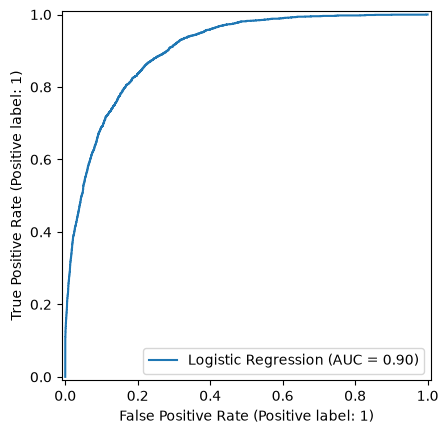

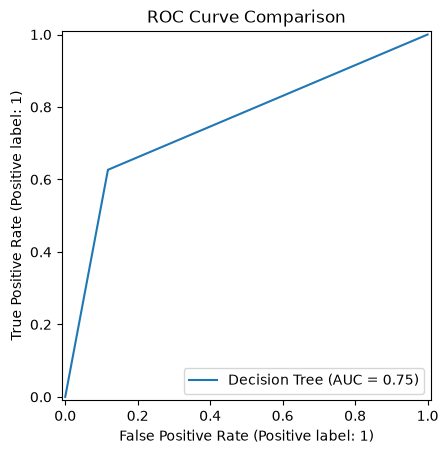

In [41]:
#ROC CURVES
%matplotlib inline
RocCurveDisplay.from_predictions(
    y_test,
    log_probability,
    name="Logistic Regression"
)
RocCurveDisplay.from_predictions(
    y_test,
    tree_probability,
    name="Decision Tree"
)
plt.title("ROC Curve Comparison")
plt.show()

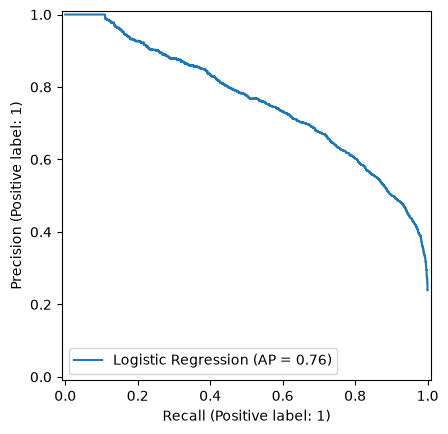

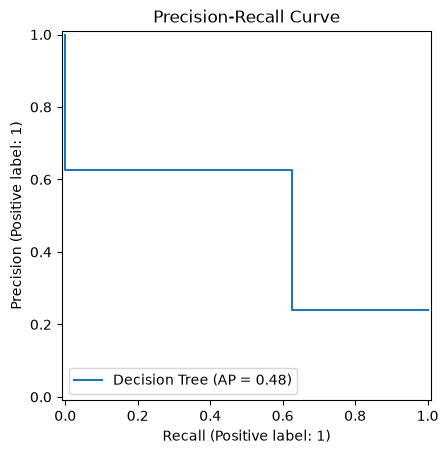

In [42]:
#Precision-Recall Curves
%matplotlib inline
PrecisionRecallDisplay.from_predictions(
    y_test,
    log_probability,
    name="Logistic Regression"
)
PrecisionRecallDisplay.from_predictions(
    y_test,
    tree_probability,
    name="Decision Tree"
)
plt.title("Precision-Recall Curve")
plt.show()

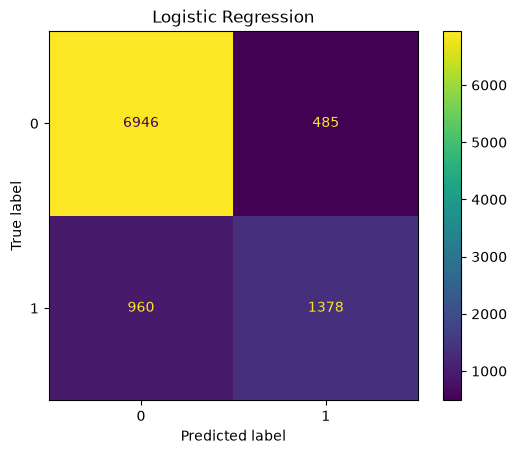

In [43]:
# Confusion Matrix-Logistic Regression
%matplotlib inline
log_cm = confusion_matrix(
    y_test,
    log_predictions
)
ConfusionMatrixDisplay(
    log_cm
).plot()
plt.title("Logistic Regression")
plt.show()

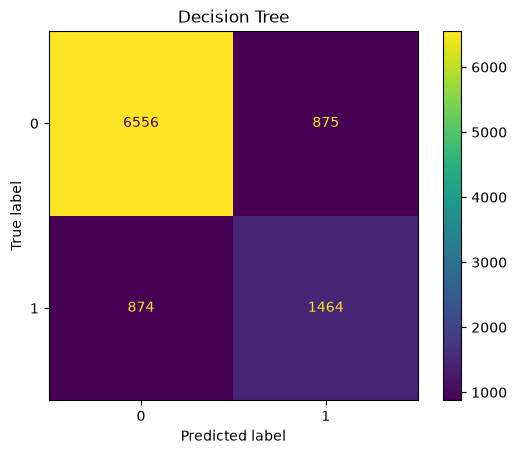

In [44]:
# Confusion Matrix-Decision Tree
%matplotlib inline
tree_cm = confusion_matrix(
    y_test,
    tree_predictions
)
ConfusionMatrixDisplay(
    tree_cm
).plot()
plt.title("Decision Tree")
plt.show()

In [45]:
print("\nInterpretation")
print(
    "Compare Precision, Recall and F1 Score for both models."
)
print(
    "Also compare False Positives and False Negatives from the confusion matrices."
)
print(
    "Since Precision is the primary business metric, the model with higher Precision "
    "is preferred because it reduces unnecessary marketing costs."
)


Interpretation
Compare Precision, Recall and F1 Score for both models.
Also compare False Positives and False Negatives from the confusion matrices.
Since Precision is the primary business metric, the model with higher Precision is preferred because it reduces unnecessary marketing costs.


In [53]:
# 1. Get Feature Names After Preprocessing
# Get fitted preprocessor from pipeline
preprocessor = logistic_pipeline.named_steps["preprocessor"]
# Get One-Hot Encoded categorical feature names
categorical_feature_names = preprocessor.named_transformers_[
    "categorical"
].named_steps["encoder"].get_feature_names_out(categorical_features)
# Combine numeric + categorical feature names
all_feature_names = numeric_features + list(categorical_feature_names)
print("Total Features:", len(all_feature_names))

Total Features: 104


In [54]:
# 2. Extract Logistic Regression Coefficients
coefficients = logistic_pipeline.named_steps["classifier"].coef_[0]
coef_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Coefficient": coefficients
})
print(coef_df.head())

         Feature  Coefficient
0            age     0.304703
1         fnlwgt     0.087865
2  education-num     0.799747
3   capital-gain     2.210683
4   capital-loss     0.268841


In [55]:
# 3. Top Positive Coefficients
top_positive = coef_df.sort_values(
    by="Coefficient",
    ascending=False
).head(10)

print("\nTop 10 Positive Features")
print(top_positive)


Top 10 Positive Features
                              Feature  Coefficient
3                        capital-gain     2.210683
31   marital-status_Married-AF-spouse     1.722195
32  marital-status_Married-civ-spouse     1.544139
83             native-country_Ireland     1.297665
64            native-country_Cambodia     0.941549
82                native-country_Iran     0.916396
72             native-country_England     0.825670
2                       education-num     0.799747
40         occupation_Exec-managerial     0.754679
56                  relationship_Wife     0.748184


In [56]:
# 4. Top Negative Coefficients
top_negative = coef_df.sort_values(
    by="Coefficient",
    ascending=True
).head(10)

print("\nTop 10 Negative Features")
print(top_negative)


Top 10 Negative Features
                            Feature  Coefficient
34     marital-status_Never-married    -1.396265
45       occupation_Priv-house-serv    -1.294359
100  native-country_Trinadad&Tobago    -1.184244
27              education_Preschool    -1.141356
53      relationship_Other-relative    -1.092647
62                       sex_Female    -1.008389
44         occupation_Other-service    -0.946654
41       occupation_Farming-fishing    -0.904849
30          marital-status_Divorced    -0.899514
35         marital-status_Separated    -0.849186


In [57]:
# 5. Logistic Regression Interpretation
print("\nInterpretation")
print(
    "Features with positive coefficients increase the chance "
    "of predicting income greater than $50K."
)
print(
    "Features with negative coefficients decrease the chance "
    "of predicting income greater than $50K."
)
print(
    "Larger coefficient values indicate stronger influence "
    "on the prediction."
)


Interpretation
Features with positive coefficients increase the chance of predicting income greater than $50K.
Features with negative coefficients decrease the chance of predicting income greater than $50K.
Larger coefficient values indicate stronger influence on the prediction.


In [58]:
# 1. Tree Information
tree_model = tree_pipeline.named_steps["classifier"]
print("Tree Depth:")
print(tree_model.get_depth())
print("\nNumber of Leaves:")
print(tree_model.get_n_leaves())

Tree Depth:
53

Number of Leaves:
3805


In [59]:
# 2. Training vs Testing Accuracy
train_score = tree_pipeline.score(
    X_train,
    y_train
)
test_score = tree_pipeline.score(
    X_test,
    y_test
)
print("\nTraining Accuracy:", train_score)
print("Testing Accuracy :", test_score)


Training Accuracy: 0.9999617941468633
Testing Accuracy : 0.8209642747466476


In [60]:
# 3. Export Tree Rules
from sklearn.tree import export_text
tree_rules = export_text(
    tree_model,
    feature_names=all_feature_names
)
print(tree_rules[:2500])

|--- marital-status_Married-civ-spouse <= 0.50
|   |--- capital-gain <= 0.83
|   |   |--- education-num <= 0.94
|   |   |   |--- capital-loss <= 5.23
|   |   |   |   |--- hours-per-week <= 0.08
|   |   |   |   |   |--- age <= -0.52
|   |   |   |   |   |   |--- marital-status_Married-AF-spouse <= 0.50
|   |   |   |   |   |   |   |--- marital-status_Widowed <= 0.50
|   |   |   |   |   |   |   |   |--- age <= -0.67
|   |   |   |   |   |   |   |   |   |--- fnlwgt <= -1.59
|   |   |   |   |   |   |   |   |   |   |--- education_Assoc-voc <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |   |   |--- education_Assoc-voc >  0.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |   |   |--- fnlwgt >  -1.59
|   |   |   |   |   |   |   |   |   |   |--- race_Asian-Pac-Islander <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 7
|   |   |   |   |   |   |   |   |   |   |--- race_Asia

In [61]:
# 4. Decision Tree Interpretation
print("\nDecision Tree Interpretation")
print(
    "Compare training and testing accuracy to identify overfitting."
)
print(
    "The first few splits represent the most important features "
    "used by the Decision Tree."
)
print(
    "If features like education, age, capital-gain or "
    "hours-per-week appear near the top, the model logic is sensible."
)


Decision Tree Interpretation
Compare training and testing accuracy to identify overfitting.
The first few splits represent the most important features used by the Decision Tree.
If features like education, age, capital-gain or hours-per-week appear near the top, the model logic is sensible.


In [62]:
from pathlib import Path
import joblib
save_path = Path(r"D:\Netixsol_Intern_Projects\Week-4\day2")
joblib.dump(logistic_pipeline, save_path / "logistic_pipeline.pkl")
joblib.dump(tree_pipeline, save_path / "decision_tree_pipeline.pkl")
print("Pipelines saved successfully!")

Pipelines saved successfully!


### Decision Tree
###### Training Accuracy = 0.9999
###### Testing Accuracy  = 0.8210

The Decision Tree achieved almost perfect training accuracy but significantly lower testing accuracy, indicating overfitting. While it learned the training data very well, its performance on unseen data decreased.

#### (Model Comparison)

The Rule-Based Baseline, Logistic Regression, and Decision Tree models were evaluated using Accuracy, Precision, Recall, F1 Score, ROC AUC, and PR AUC. Logistic Regression achieved the best overall performance with 85.21% Accuracy, 73.97% Precision, 65.60% F1 Score, 0.903 ROC AUC, and 0.761 PR AUC. Although the Decision Tree produced a slightly higher Recall (62.62%), it performed worse than Logistic Regression on all other evaluation metrics.

#### (Model Selection)

*Logistic Regression* will be selected for further development because it achieved the highest Precision, which is the primary business objective for this project. A higher Precision means fewer false positives, reducing unnecessary marketing costs by targeting customers who are more likely to have an income above $50K. In contrast, the Decision Tree showed signs of overfitting, achieving almost perfect training accuracy (99.99%) but only 82.10% testing accuracy. Therefore, Logistic Regression provides better generalization and is a more reliable model for future improvement.

#### Future Improvements (Day 3)

The preprocessing pipeline developed in this notebook will be reused to ensure consistent data preparation and prevent data leakage. On Day 3, the models will be improved by tuning hyperparameters, testing different preprocessing strategies, engineering additional features, and experimenting with more advanced algorithms. The primary goal will remain improving Precision while maintaining strong Recall and F1 Score.